# 5 - TEXT PREPROCESSING 

# 1. Tổng quan:
## 1.1. Chủ đề dữ liệu

Bộ dữ liệu IMDb 50K Movie Reviews tập trung vào bài toán dự đoán cảm xúc của người dùng dựa trên các bài đánh giá phim. Mỗi mẫu dữ liệu bao gồm nội dung văn bản của một bài review và nhãn cảm xúc tương ứng tích cực hoặc tiêu cực.

Bộ dữ liệu được dùng thuộc dataset IMDB Dataset of 50K Movie Reviews
Sau khi rút gọn dataset thì dataset còn 10000 mẫu và có 2 nhãn phân loại

Trong file Movie_Reviews.csv có 2 cột là review và sentiment
- review: gồm text
- sentiment: Là nhãn gồm positive và negative

## 1.2. Nguồn dữ liệu
- Nền tảng: Kaggle
- Tên bộ dữ liệu: IMDb Dataset of 50K Movie Reviews
- URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- Tác giả: Lakshmi Narayanan Pathi (tổng hợp từ IMDb)
- Nguồn công bố: Dữ liệu đánh giá phim từ Internet Movie Database (IMDb)
- Năm cập nhật: 2018 

## 1.3 Nội dung 
- Phân tích thống kê văn bản (Text EDA)
    - Phân phối độ dài và kiểm định Mann-Whitney U
    - Word Cloud và type-token ratio
    - Phân phối Zipf
- Các kỹ thuật tiền xử lý và phân tích tác động
    - Pipeline chuẩn hóa văn bản
    - So sánh chiến lược tokenization
    - Loại bỏ stop words và phân tích thông tin
    - Stemming, Lemmatization và so sánh định lượng
    - Vector hóa văn bản và phân tích không gian đặc trưng
    - Biểu diễn ngữ nghĩa bằng Sentence Transformer

# 2. Nội dung notebook

In [7]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from tokenizers import Tokenizer, models, pre_tokenizers, trainers

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import mutual_info_classif

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from scipy.stats import mannwhitneyu

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
import os

SAVE_DIR = os.path.join("..", "data", "processed", "processed_text")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Thư mục lưu processed data: {os.path.abspath(SAVE_DIR)}")

Thư mục lưu processed data: d:\Study\Data_Mining\Group_3\data\processed\processed_text


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VU\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VU\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VU\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\VU\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
# Load dữ liệu
df = pd.read_csv('../data/raw/Movie_Reviews.csv')

# 1. Tính độ dài văn bản
# Số ký tự
df['char_count'] = df['review'].apply(len)
# Số từ (tách theo khoảng trắng cơ bản vì chưa tiền xử lý)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment  char_count  \
0  One of the other reviewers has mentioned that ...  positive        1761   
1  A wonderful little production. <br /><br />The...  positive         998   
2  I thought this was a wonderful way to spend ti...  positive         926   
3  Basically there's a family where a little boy ...  negative         748   
4  Petter Mattei's "Love in the Time of Money" is...  positive        1317   

   word_count  
0         307  
1         162  
2         166  
3         138  
4         230  
sentiment
positive    5028
negative    4972
Name: count, dtype: int64


## 2.1 Phân tích thống kê văn bản (Text EDA)

### 2.1.1 Phân phối độ dài và kiểm định Mann-Whitney U

#### Kiểm định Mann-Whitney U
So sánh 2 nhóm độc lập xem chúng có khác nhau về phân phối hay không.

Tổng hạng
- $R_1 = \sum_{i=1}^{n_1} \text{rank}(x_i), \quad R_2 = \sum_{j=1}^{n_2} \text{rank}(y_j)$
- Thống kê U
$$
U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}
$$

$$
U_2 = R_2 - \frac{n_2(n_2 + 1)}{2}
$$
Chọn giá trị U
$$
U = \min(U_1, U_2)
$$

Sau khi có U thì so sánh với kỳ vòng, chuẩn hóa và với kết quả đó thì có thể hiểu được 2 nhóm có khác nhau về phân phối hay không

Đã lưu biểu đồ tại: ..\data\processed\processed_text\word_count_distribution.png


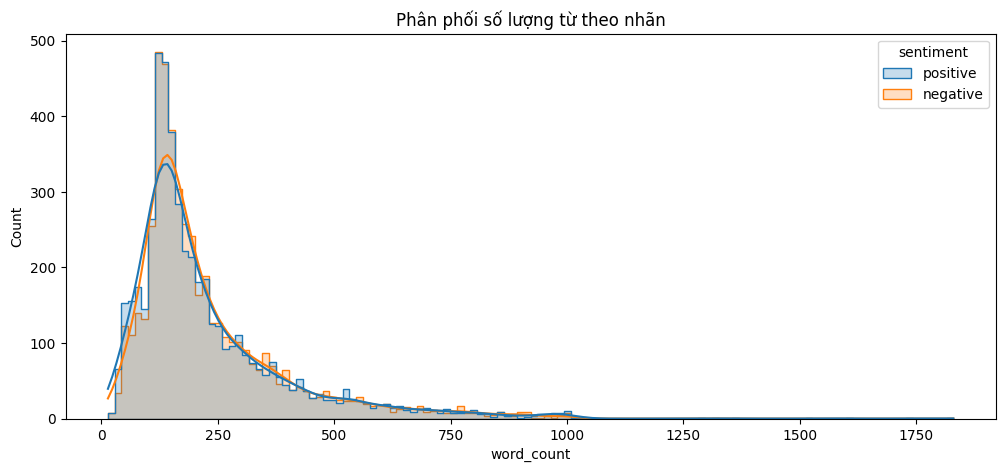

--- Thống kê cho word_count ---
             count        mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   4972.0  232.440668  166.187922  14.0  128.0  175.0  283.0  1316.0
positive   5028.0  229.819014  176.479155  21.0  124.0  169.0  280.0  1830.0
Đã lưu biểu đồ tại: ..\data\processed\processed_text\char_count_distribution.png


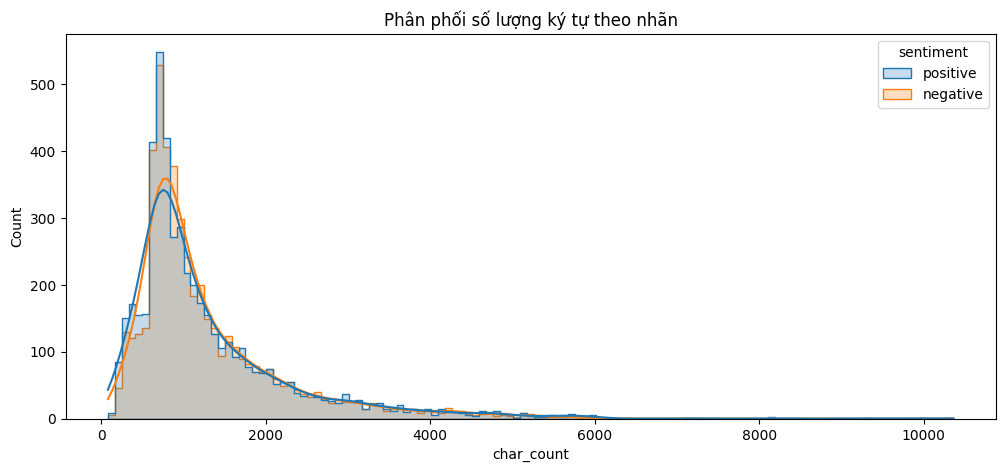

--- Thống kê cho char_count ---
             count         mean          std    min    25%    50%      75%  \
sentiment                                                                   
negative   4972.0  1311.295253   951.672961   80.0  710.0  971.0  1602.00   
positive   5028.0  1307.479515  1024.379033  122.0  683.0  954.0  1596.75   

               max  
sentiment           
negative    7164.0  
positive   10363.0  

Kiểm định Mann-Whitney U cho Word Count:
Statistics=12095528.500, p-value=0.0051187043


In [9]:
def plot_dist(column, title):
    plt.figure(figsize=(12, 5))
    sns.histplot(data=df, x=column, hue='sentiment', kde=True, element="step")
    plt.title(title)

    save_path = os.path.join(SAVE_DIR, f"{column}_distribution.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    
    plt.show()

    # Tính toán thống kê mô tả
    stats = df.groupby('sentiment')[column].describe()
    print(f"--- Thống kê cho {column} ---\n", stats)

# Vẽ phân phối
plot_dist('word_count', 'Phân phối số lượng từ theo nhãn')
plot_dist('char_count', 'Phân phối số lượng ký tự theo nhãn')

# Kiểm định Mann-Whitney U
pos_len = df[df['sentiment'] == 'positive']['word_count']
neg_len = df[df['sentiment'] == 'negative']['word_count']
stat, p = mannwhitneyu(pos_len, neg_len)

print(f"\nKiểm định Mann-Whitney U cho Word Count:")
print(f"Statistics={stat:.3f}, p-value={p:.10f}")

Phân phối độ dài và Kiểm định Mann-Whitney U
   - Về hình dạng phân phối, ta thấy ở cả phân phối theo số lượng từ và theo ký tự bị lệch phải
   - Phần lớn review tích cực có số lượng từ và ký tự trung bình lần lượt là 230 và 1308
   - Phần lớn review tiêu cực có số lượng từ và ký tự trung bình lần lượt là 233 và 1312
   -> Đa phần review tiêu cực sẽ có độ dài về từ và ký tự dài hơn review tích cực (Dựa theo giá trị Mean)
   -  Với giá trị P-value=0.0051187043 < 0.05 -> có sự khác biệt đáng kể về độ dài giữa 2 lớp
   -  Có outliear xuất hiện
         + Với review tích cực có review có số lượng từ nhiều nhất lên đến 1830, có ký tự nhiều nhất 10363
         + Với review tiêu cực, có review có số lượng từ nhiều nhất là 1316, có ký tự nhiều nhất là 7164
    -> Outlier ở review tiêu cực và tích cực có giá trị số lượng từ và số lượng ký tự đặc biệt lớn so với giá trị mean của chúng, Outliear này là những giá trị nhiễu, có thể làm mô hình overfitting với các giá trị này nếu huấn luyện quá nhiều epoch hoặc làm cho mô hình huấn luyện lâu hơn do gặp các giá trị nhiễu, các review này có thể gây lỗi bộ nhớ hoặc làm loãng đặc trưng của các câu ngắn

### 2.1.2 Word Cloud và type-token ratio
#### Word Cloud
Word Cloud là kỹ thuật trực quan hóa tần suất từ trong tập văn bản, Từ xuất hiện càng nhiều → hiển thị càng lớn, phương pháp này giúp:
- Nhìn nhanh chủ đề chính
- Phát hiện từ khóa nổi bật
- Kiểm tra stopwords / noise
#### type-token ratio - TTR
TTR đo độ đa dạng từ vựng (lexical diversity):
- Type = từ khác nhau
- Token = tổng số từ
Công thức:
$$
TTR = \frac{|V|}{N}
$$
Trong đó:
- ∣V∣: số từ khác nhau (vocabulary size)
- N: tổng số từ (tokens)
Có ý nghĩa giúp ta xem được bộ dữ liệu có ngôn ngữ đa dạng hay thường xuyên lặp từ


--- Nhãn: POSITIVE ---
Type-Token Ratio (TTR): 0.0797
Top 5 từ phổ biến: [('the', 64708), ('and', 34014), ('a', 31998), ('of', 30046), ('to', 25488)]
Đã lưu biểu đồ tại: ..\data\processed\processed_text\wordcloud_positive.png


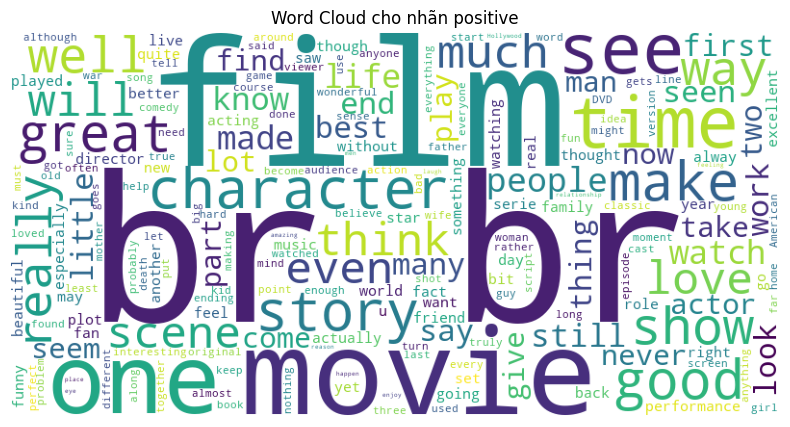


--- Nhãn: NEGATIVE ---
Type-Token Ratio (TTR): 0.0776
Top 5 từ phổ biến: [('the', 63212), ('a', 31297), ('and', 28674), ('of', 27228), ('to', 27183)]
Đã lưu biểu đồ tại: ..\data\processed\processed_text\wordcloud_negative.png


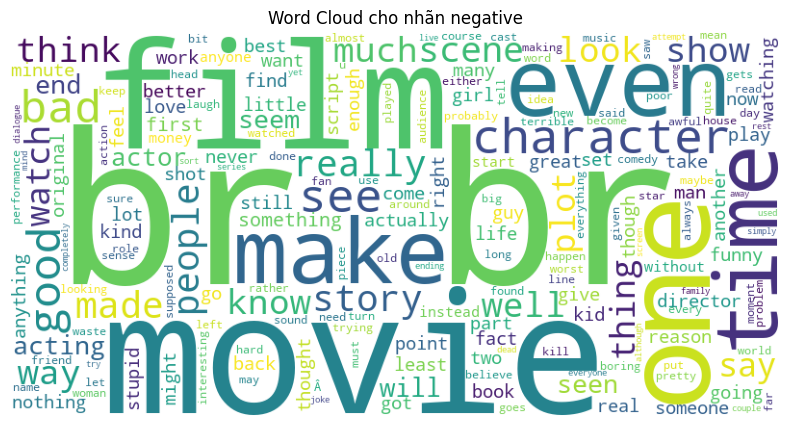

In [10]:
def calculate_ttr(text_list):
    tokens = " ".join(text_list).lower().split()
    types = set(tokens)
    return len(types) / len(tokens) if len(tokens) > 0 else 0

for label in ['positive', 'negative']:
    subset = df[df['sentiment'] == label]['review']
    
    # Tính TTR
    ttr = calculate_ttr(subset)
    print(f"\n--- Nhãn: {label.upper()} ---")
    print(f"Type-Token Ratio (TTR): {ttr:.4f}")
    
    # Top 50 từ
    words = " ".join(subset).lower().split()
    top_50 = Counter(words).most_common(50)
    print(f"Top 5 từ phổ biến: {top_50[:5]}")
    
    # Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(subset))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.title(f"Word Cloud cho nhãn {label}")
    save_path = os.path.join(SAVE_DIR, f"wordcloud_{label}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    plt.axis('off')
    plt.show()

Word Cloud, Top-50 và TTR
   - Top 50 từ phổ biến của của cả review tích cực và tiêu cực tương đối giống nhau khi nhìn về top-5 của chúng, cả 2 đều có top 5 là: the, and, a, of, to, điểm giống nhau là chúng đều là stop words -> điều này cho thấy trong việc phân tích text bàn đầu thì nêu bỏ đi các stop words vì chúng không thể hiện được đặc trưng của nhãn, chúng xuất hiện nhiều ở cả 2 nhãn
   - Có sự khác biệt nội dung khi nhìn vào Word Cloud của 2 loại review, ngoài những từ có chủ đề liên quan đến phim thì review tích cực sẽ có các tính từ thể hiện sự tích cực như: great, excelent, best, good, love,... còn những review tiêu cực sẽ có các tính từ liên quan đến sự tiêu cực như: awful, bad, hard, stupid, terible,.... Word cloud này ta không thấy các stop words dù chúng xuất hiện rất nhiều do trong Python tự loại bỏ các stop word bằng danh sách có sẵn của nó khi vẽ word cloud
   - So sánh về giá trị TTR của 2 loại review thì thấy review tích cực có giá trị lớn hơn review tiêu cực, nhưng không đánh kể 0.0797 > 0.0776
     -> Giá trị này tương đối thấp và nằm ở cả 2 loại review cho thấy cách dùng từ của cả 2 nhóm tương đối bình thường, không phong phú, và với một bộ dữ liệu lớn thì có giá trị TTR như thế này cho thấy khi tập dữ liệu lớn hơn nữa thì giá trị token tăng nhanh nhưng số lượng từ mới là type tăng chậm

### 2.1.3 Phân phối Zipf
Tần suất của một từ tỉ lệ nghịch với thứ hạng của nó trong bảng tần suất.
$$
f(r) = \frac{C}{r^s}
$$

Trong đó:
- f(r): tần suất của từ có rank r
- r: thứ hạng (1 = từ phổ biến nhất)
- s≈1: hằng số (thường gần 1)
- C: hằng số chuẩn hóa

Phương pháp giúp ta thấy bộ dữ liệu có ít từ xuất hiện rất nhiều
hoặc rất nhiều từ xuất hiện rất ít, từ đó đương ra các phương án giải quyết

Đã lưu biểu đồ tại: ..\data\processed\processed_text\zipf_plot.png


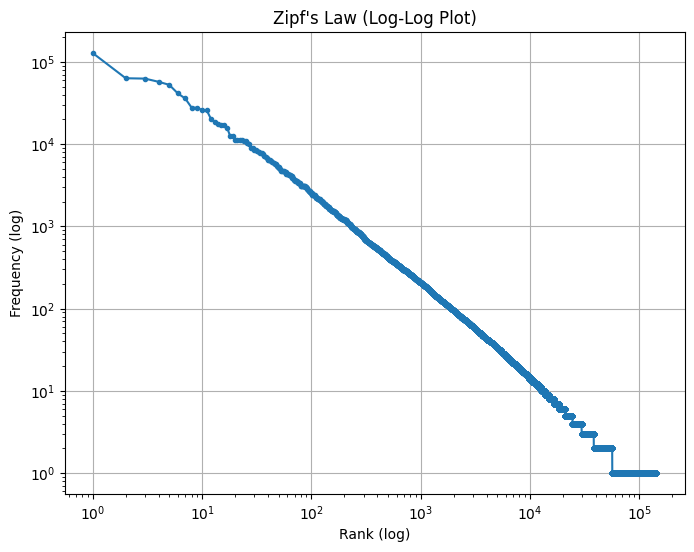

In [11]:
def plot_zipf(text_list):
    words = " ".join(text_list).lower().split()
    counts = Counter(words)
    frequencies = sorted(counts.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)
    
    plt.figure(figsize=(8, 6))
    plt.loglog(ranks, frequencies, marker=".")
    plt.title("Zipf's Law (Log-Log Plot)")
    plt.xlabel("Rank (log)")
    plt.ylabel("Frequency (log)")
    plt.grid(True)
    save_path = os.path.join(SAVE_DIR, "zipf_plot.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    plt.show()

plot_zipf(df['review'])

Phân tích phân phối Zipf
- Đường biểu đồ log-log cho frequency và rank gần như 1 đường thẳng đi xuống, nó tuân theo quy luật Zipf là tần xuất tỉ lể nghịch với thứ hạng của nó -> ngôn ngữ của các bài review vẫn có tính tự nhiên, các từ có thứ hạng 1, 2,... thì tần suất xuất hiện nó càng nhiều nhưng chúng lại là các stop words không mang ý nghĩa, trong khi những từ thể hiện được tính đặc trưng thì tần suất chúng lại thấp -> một cách để khắc phục được điều này là dùng BPE để chuyển đổi các từ đó về dạng gốc, giúp tăng tần suất xuất hiện của chúng lên

## 2.2 Kỹ thuật tiền xử lý và phân tích tác động
### 2.2.1 Pipeline chuẩn hóa văn bản
Mục tiêu của Pipeline là chuẩn hóa văn bản để:
- Giảm noise (HTML, URL, ký tự rác)
- Chuẩn hóa biểu diễn
- Ổn định phân phối độ dài và vocabulary
Pipeline chuẩn hóa gồm các bước
- Lowercase
- Loại HTML, URL, mentio, hashtag
- Loại ký tự đặc biệt & số (có điều kiện)
- Chuẩn hóa khoảng trắng

Xây dựng Pipeline chuẩn hóa văn bản giúp Giảm duplicate, loại noise, thông tin không hữu ít, giảm sparsity, chuẩn hóa format
-> Giúp giảm dimensionality, length distribution ổn định hơn và model học tốt hơn


In [12]:
# Tạo bản sao dữ liệu để xử lý
df_clean = df.copy()

def get_stats(text_series):
    # Tính số từ vựng duy nhất và độ dài trung bình (tính theo số từ)
    words = " ".join(text_series).split()
    vocab_size = len(set(words))
    avg_len = np.mean(text_series.apply(lambda x: len(str(x).split())))
    return vocab_size, avg_len

stats = []
stats.append(('Original', *get_stats(df_clean['review'])))

# 1. Lowercase
df_clean['step1'] = df_clean['review'].str.lower()
stats.append(('1. Lowercase', *get_stats(df_clean['step1'])))

# 2. Xóa HTML 
df_clean['step2'] = df_clean['step1'].apply(lambda x: re.sub(r'<.*?>', ' ', x))
stats.append(('2. Remove HTML', *get_stats(df_clean['step2'])))

# 3. Xóa URL/Mention/Hashtag
df_clean['step3'] = df_clean['step2'].apply(lambda x: re.sub(r'http\S+|www\S+|@\w+|#\w+', '', x))
stats.append(('3. Remove URL/Tags', *get_stats(df_clean['step3'])))

# 4. Xóa ký tự đặc biệt và số (Chỉ giữ lại a-z và khoảng trắng)
df_clean['step4'] = df_clean['step3'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
stats.append(('4. Remove Special/Num', *get_stats(df_clean['step4'])))

# 5. Chuẩn hóa khoảng trắng
df_clean['cleaned_text'] = df_clean['step4'].apply(lambda x: " ".join(x.split()))
stats.append(('5. Normalize Whitespace', *get_stats(df_clean['cleaned_text'])))

# Tạo DataFrame
stats_df = pd.DataFrame(stats, columns=['Step', 'Vocab Size', 'Avg Word Length'])

# Thêm cột tính toán sự thay đổi so với bước liền trước
stats_df['Vocab Change'] = stats_df['Vocab Size'].diff().fillna(0).astype(int)
stats_df['Avg Length Change'] = stats_df['Avg Word Length'].diff().fillna(0).round(2)

# Sắp xếp lại thứ tự cột cho dễ nhìn
stats_df = stats_df[['Step', 'Vocab Size', 'Vocab Change', 'Avg Word Length', 'Avg Length Change']]
print(stats_df)

                      Step  Vocab Size  Vocab Change  Avg Word Length  \
0                 Original      158391             0         231.1225   
1             1. Lowercase      143299        -15092         231.1225   
2           2. Remove HTML      135324         -7975         228.7986   
3       3. Remove URL/Tags      135251           -73         228.7909   
4    4. Remove Special/Num       51727        -83524         234.0299   
5  5. Normalize Whitespace       51727             0         234.0299   

   Avg Length Change  
0               0.00  
1               0.00  
2              -2.32  
3              -0.01  
4               5.24  
5               0.00  


 Pipeline chuẩn hóa văn bản, phân tích tỉ lệ từ vựng thay đổi và tác động đến phân phối độ dài văn bản với mỗi bước
   - Lowercase: ta thấy vocab size giảm 15092 và Avg Word Length giữ nguyên so với original, vì khi lowercase thì những từ trước đó được tính là 2 do 1 từ viết hoa, 1 từ viết thường thì giờ đây đã trở thành 1, lowercase thì không xóa từ trong sample nên avg word length không đổi
   - Remove HTML: Nhờ vào việc xóa HTML là xóa từ khỏi sample nên cả vocab size và avg word length đều giảm
   - Remove URL/Tags: tương tự remove HTML nhưng có vẻ giảm không nhiều
   - Remove Special/Num: giảm được cả vocab size nhiều nhất do không chỉ là xóa số, ký tự đặc biệt bình thường mà chỉ cần từ có hay vô tình chứa số hoặc ký tự đặt biệt, nó xóa ký tự đặt biệt đó đi và từ mới nhận được là 1 từ đã có trong vocabulary nên số lượng giảm xuống đáng kể, đặc biệt là giá trị avg word length không giảm mà lại tăng là do có 1 số từ đặc biệt như don't, well-know,... khi bỏ ký tự đặt biệt thì nó biến từ 1 ành 2 từ dẫn đến độ dài tăng
   - Normalize Whitespace: không giảm được gí trị của thuộc tính nào cả do trong code ta dùng hàm split(), hàm này bỏ qua các khoảng trắng dư thừa rồi, nên trong thực tên bước normalize quan trọng do nó làm gọn được string
   => Ta thấy xóa số, ký tự đặc biệt là giảm được Vocab size và cả Avg word length nhiều nhất nhưng việc này cũng không hoàn toàn có lợi, dù có thể xóa cá dấu câu, ký hiệu đặc biệt, những từ có trong Vocabulary rồi nhưng lỡ dính với số hoặc ký tự đặc biệt nên trở thành 1 từ mới, những từ này không mang lại thông tin quan trọng nên xóa đi là tốt nhưng cũng có 1 số trường hợp mang thông in đặc trưng rất rõ (ví dụ như: "10/10", "A+", ...) nhưng những từ này cũng không dễ để ta xác định thành 1 tập hợp, từ đó mà có thể giữ lại. Trong trường hợp này ta có lượng chọn đánh đổi là xóa chúng để vocab size nhỏ hơn, ít nhiễu hơn.

### 2.2.2 So sánh chiến lược tokenization
Tokenization là quá trình chuyển văn bản: Text → chuỗi token

Mỗi chiến lược định nghĩa token khác nhau → ảnh hưởng trực tiếp đến:
- Kích thước từ vựng
- Tỷ lệ OOV

Các chiến lược tokenization:
- Word-level Tokenization: Tách văn bản thành từ dựa trên whitespace, punctuation, rule-based (NLTK, spaCy)
- Sentence-level Tokenization: tách văn bản thành câu, mỗi câu là 1 token
- Character-level Tokenization: tách văn bản thành ký tự, Vocabulary rất nhỏ, Không có OOV, Chuỗi rất dài
- Subword Tokenization (BPE): kết hợp giữa Word-level và Sentence-level, học các subword phổ biến -> Vocabulary vừa phải, Giảm OOV, Giữ được cấu trúc từ

In [13]:
# Chia Train/Test (Dùng cột đã clean ở bước a)
X_train, X_test = train_test_split(df_clean['cleaned_text'], test_size=0.2, random_state=42)

def eval_tokenization(name, train_tokens_list, test_tokens_list):
    # Tạo từ điển từ tập Train
    train_vocab = set([token for seq in train_tokens_list for token in seq])
    vocab_size = len(train_vocab)
    
    # Tính OOV trên tập Test
    test_tokens = [token for seq in test_tokens_list for token in seq]
    if len(test_tokens) == 0: oov_rate = 0
    else:
        oov_count = sum(1 for token in test_tokens if token not in train_vocab)
        oov_rate = oov_count / len(test_tokens)
        
    # Tính độ dài chuỗi trung bình
    avg_len = np.mean([len(seq) for seq in train_tokens_list])
    
    print(f"--- {name} ---")
    print(f"Vocab size: {vocab_size:,} | OOV Rate: {oov_rate*100:.2f}% | Avg Seq Length: {avg_len:.1f}")

# 1. Word-level (NLTK)
train_word = [word_tokenize(text) for text in X_train]
test_word = [word_tokenize(text) for text in X_test]
eval_tokenization("Word-level (NLTK)", train_word, test_word)

# 2. Sentence-level (Dùng văn bản gốc để thấy rõ câu, vì text clean mất dấu chấm)
train_sent = [sent_tokenize(text) for text in df_clean.loc[X_train.index, 'review']]
test_sent = [sent_tokenize(text) for text in df_clean.loc[X_test.index, 'review']]
eval_tokenization("Sentence-level", train_sent, test_sent)

# 3. Character-level
train_char = [list(text.replace(" ", "")) for text in X_train]
test_char = [list(text.replace(" ", "")) for text in X_test]
eval_tokenization("Character-level", train_char, test_char)

# 4. Subword (BPE HuggingFace)
# Khởi tạo mô hình BPE
tokenizer_bpe = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer_bpe.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(vocab_size=5000, special_tokens=["[UNK]"])
# Train BPE trên tập Train
tokenizer_bpe.train_from_iterator(X_train, trainer=trainer)

train_bpe = [tokenizer_bpe.encode(text).tokens for text in X_train]
test_bpe = [tokenizer_bpe.encode(text).tokens for text in X_test]
eval_tokenization("Subword (BPE - Vocab 5000)", train_bpe, test_bpe)

--- Word-level (NLTK) ---
Vocab size: 47,054 | OOV Rate: 1.24% | Avg Seq Length: 234.2
--- Sentence-level ---
Vocab size: 83,717 | OOV Rate: 97.85% | Avg Seq Length: 10.6
--- Character-level ---
Vocab size: 26 | OOV Rate: 0.00% | Avg Seq Length: 1015.3
--- Subword (BPE - Vocab 5000) ---
Vocab size: 4,974 | OOV Rate: 0.00% | Avg Seq Length: 277.4


2. So sánh chiến lược Tokenization
   - Nhìn vào kết quả kích thước từ vựng,, tỉ lệ OOV trên tập test, độ dài chuỗi token trung bình, xét với level của charater, word, sentence ta có thể đưa ra 1 số nhận xét như sau
     + Kích thước từ vựng (Vocab Size):
            + Ở charater-level là nhỏ nhất vì đây là số lượng loại chữ cái trên tập train, 26 ứng với toàn bộ chữ cái trên bảng chữ cái tiếng anh, nhưng việc này làm mất hoàn toàn ngư nghĩa của chúng
           + Lớn hơn lần lượt là của word-level và sentence-level, với chúng là số lượng từ khác nhau, số lượng câu khác nhau trên tập train, số lượng câu khác nhau là lớn nhất vì hầu như không có câu nào là giống hoàn toàn câu nào.
     + Tỉ lệ OOV trên tập test:
            + Nhỏ nhất là của charater-level vì không có chữ cái nào khác bảng chữ cái tiếng anh mà nằm trong tập test
           + Lớn hơn là word-level với giá trị 1.24%, đây cũng là 1 giá trị khá tốt khi trên tập test chỉ có hơn 1% từ không nằm ở tập train
           + Còn lớn nhất là sentence-level cũng như đã nói ở trên vì hầu như mọi câu không giống nhau hoàn toàn
     + Độ dài chuỗi token trung bình (Avg Seq Length):
           + Nhỏ nhất là sentence-level vi mỗi sample có số lượng câu không quá lớn nên trung bình của chúng trên tập train chỉ là 10.6
           + Khác với nó, word-level và charater-level lớn hơn rất nhiều do 1 sample có thể có nhiều từ, rất nhiều chữ
     => Khi 3 level trên đều có khuyết điểm của mình thì chiến lượt tokenization  subword lại cho kết quả rất tốt với Vocab size, OOV rate, Avg Seq Length lần lượt là 4974, 0%, 277.4, vì thế nếu được lựa chọn thì đây là chiến lượt tốt nhất nhờ nguyên tắc của nó là từ phổ biến thì giữ nguyên, từ hiếm thì được cắt nhỏ ra

### 2.2.3 Loại bỏ stop words và phân tích thông tin
Stop words là các từ xuất hiện rất thường xuyên nhưng mang ít thông tin phân biệt

Loại bỏ chúng giúp:
- Giảm noise
- Giảm dimensionality
- Tăng khả năng học của mô hình

Mutual Information (MI): đo mức độ liên quan giữa từ và nhãn

$$
MI(t, y) = \sum_{t \in \{0,1\}} \sum_{y \in \mathcal{Y}} 
P(t, y) \log \frac{P(t, y)}{P(t)P(y)}
$$

Trong đó:
- t: sự xuất hiện của từ (0/1)
- y: nhãn (class)

Hiệu năng Naive Bayes
$$
P(y|d) \propto P(y) \prod_{i} P(t_i | y)
$$

In [14]:
y = df_clean['sentiment'].map({'positive': 1, 'negative': 0})
texts = df_clean['cleaned_text']

# Lấy danh sách stop words của NLTK
stop_words = set(stopwords.words('english'))

# Hàm loại bỏ stop words
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

texts_no_stop = texts.apply(remove_stopwords)

def analyze_representation(text_data, y, name):
    # Biến đổi thành Ma trận đếm (BoW)
    vectorizer = CountVectorizer() 
    X = vectorizer.fit_transform(text_data)
    
    vocab_size = len(vectorizer.vocabulary_)
    
    print(f"Đang tính Mutual Information cho: {name}...") 
    
    # Tính MI trung bình trên toàn bộ dữ liệu
    mi_scores = mutual_info_classif(X, y)
    avg_mi = np.mean(mi_scores)
    
    # Tính hiệu năng Naive Bayes bằng 5-fold CV
    nb = MultinomialNB()
    cv_scores = cross_val_score(nb, X, y, cv=5, scoring='accuracy')
    avg_acc = np.mean(cv_scores)
    
    print(f"--- {name} ---")
    print(f"Vocab Size: {vocab_size:,}")
    print(f"Average MI: {avg_mi:.6f}")
    print(f"Naive Bayes 5-fold CV Accuracy: {avg_acc:.4f}\n")

# Chạy phân tích
analyze_representation(texts, y, "Trạng thái: GIỮ LẠI Stop Words")
analyze_representation(texts_no_stop, y, "Trạng thái: ĐÃ LOẠI BỎ Stop Words")

Đang tính Mutual Information cho: Trạng thái: GIỮ LẠI Stop Words...
--- Trạng thái: GIỮ LẠI Stop Words ---
Vocab Size: 51,701
Average MI: 0.000149
Naive Bayes 5-fold CV Accuracy: 0.8384

Đang tính Mutual Information cho: Trạng thái: ĐÃ LOẠI BỎ Stop Words...
--- Trạng thái: ĐÃ LOẠI BỎ Stop Words ---
Vocab Size: 51,557
Average MI: 0.000144
Naive Bayes 5-fold CV Accuracy: 0.8495



Loại bỏ Stop words và phân tích (Kích thước, MI, Hiệu năng)
   - Sau khi loại bỏ stop words, vocab giảm đi 144 từ và MI trung bình cũng giảm, đại lượng MI thể hiện thông tin mà 1 từ đóng góp vào nhãn nên nhưng not, no, very,... bỏ những từ này đôi lúc ảnh hưởng rất nhiều đến việc phân loại nhãn vì chúng có giá trị MI cao
   - Accuracy sau khi bỏ stop words có tăng do stop mang thông tin không giá trị mà lại có số lượng rất lớn, bỏ đi chúng giúp mô hình tập trung vào các từ có ý nghĩa quan trọng hơn
   - Việc loại bỏ stop word đôi khi cũng không làm tốt kết quả theo hướng ta muốn nhưng việc loại bỏ chúng có thể làm việc tính toán nhanh hơn

### 2.2.4 Stemming, Lemmatization và so sánh định lượng
Stemming vs Lemmatization
- Stemming:	Cắt bỏ hậu tố theo rule
- Lemmatization: Đưa từ về dạng từ điển (lemma)

Các phương pháp
- Porter Stemmer: Rule-based, Cắt hậu tố ing, ed, ly
- Snowball Stemmer: Phiên bản cải tiến của Porter, nhất quán hơn, hỗ trợ nhiều ngôn ngữ
- WordNet Lemmatizer: Dựa trên từ điển WordNet, Cần POS (part-of-speech) để chính xác

Collision Rate: Tỉ lệ các từ khác nhau bị ánh xạ về cùng một dạng gốc
Giả sử:
- V: tập từ ban đầu
- V′: tập sau xử lý
$$
\text{Collision Rate} = 1 - \frac{|V'|}{|V|}
$$
Ý nghĩa
- Cao → nhiều từ bị “gộp lại”
- Thấp → giữ nguyên nhiều từ

In [15]:
# Khởi tạo các công cụ
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

all_words = " ".join(df_clean['cleaned_text']).split()
unique_words = list(set(all_words))

def calculate_collision_rate(words, method_func):
    """Tính tỉ lệ các từ ban đầu khác nhau nhưng bị biến đổi thành cùng một dạng"""
    mapped_words = [method_func(w) for w in words]
    original_count = len(words)
    unique_mapped_count = len(set(mapped_words)) # Số gốc từ duy nhất sau khi biến đổi
    
    # Collision Rate = (Số từ ban đầu - Số gốc từ duy nhất) / Số từ ban đầu
    # Tỉ lệ này càng cao nghĩa là phương pháp gộp càng nhiều từ khác nhau thành 1
    collision_rate = (original_count - unique_mapped_count) / original_count
    return collision_rate, unique_mapped_count

def evaluate_classification(text_data, y, name):
    # Dùng TF-IDF đơn giản để đánh giá
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(text_data)
    
    # Logistic Regression 5-fold CV
    lr = LogisticRegression(max_iter=1000)
    scores = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
    
    print(f"--- {name} ---")
    print(f"LR 5-fold Accuracy: {np.mean(scores):.4f} (std: {np.std(scores):.4f})\n")

print("Dataset có ", len(unique_words))
# 1. Tính Collision Rate
print("--- Collision Rate trên toàn dataset ---")
cr_porter, count_porter = calculate_collision_rate(unique_words, porter.stem)
print(f"Porter Stemmer: {cr_porter*100:.2f}% (Còn {count_porter} gốc từ)")

cr_snowball, count_snowball = calculate_collision_rate(unique_words, snowball.stem)
print(f"Snowball Stemmer: {cr_snowball*100:.2f}% (Còn {count_snowball} gốc từ)")

# Lemmatizer mặc định coi từ là danh từ (noun), nếu muốn chính xác phải thêm tag POS (verb, adj...)
cr_lemma, count_lemma = calculate_collision_rate(unique_words, lemmatizer.lemmatize)
print(f"WordNet Lemmatizer: {cr_lemma*100:.2f}% (Còn {count_lemma} gốc từ)\n")

# 2. Tạo tập dữ liệu mới và Đánh giá hiệu năng
print("Đang chuẩn bị dữ liệu Stemming/Lemmatization")

sample_texts = df_clean['cleaned_text']
sample_y = df_clean['sentiment'].map({'positive': 1, 'negative': 0})

texts_porter = sample_texts.apply(lambda x: " ".join([porter.stem(w) for w in x.split()]))
texts_snowball = sample_texts.apply(lambda x: " ".join([snowball.stem(w) for w in x.split()]))
texts_lemma = sample_texts.apply(lambda x: " ".join([lemmatizer.lemmatize(w) for w in x.split()]))

print("Đang đánh giá hiệu năng...")
evaluate_classification(sample_texts, sample_y, "1. Original Cleaned Text")
evaluate_classification(texts_porter, sample_y, "2. Porter Stemmer")
evaluate_classification(texts_snowball, sample_y, "3. Snowball Stemmer")
evaluate_classification(texts_lemma, sample_y, "4. WordNet Lemmatizer")

Dataset có  51727
--- Collision Rate trên toàn dataset ---
Porter Stemmer: 32.34% (Còn 35001 gốc từ)
Snowball Stemmer: 33.19% (Còn 34557 gốc từ)
WordNet Lemmatizer: 10.73% (Còn 46176 gốc từ)

Đang chuẩn bị dữ liệu Stemming/Lemmatization
Đang đánh giá hiệu năng...
--- 1. Original Cleaned Text ---
LR 5-fold Accuracy: 0.8754 (std: 0.0061)

--- 2. Porter Stemmer ---
LR 5-fold Accuracy: 0.8741 (std: 0.0094)

--- 3. Snowball Stemmer ---
LR 5-fold Accuracy: 0.8738 (std: 0.0082)

--- 4. WordNet Lemmatizer ---
LR 5-fold Accuracy: 0.8756 (std: 0.0058)



Stemming, Lemmatization và so sánh Collision Rate, hiệu năng
- Từ dataset có 51717 từ, Stemming và Lemmatization sẽ cắt từ về từ gốc
  
  + Với 2 phương pháp Stemming thì cắt giảm từ rất nhiều, còn 35001 gốc từ với Porter và 34557 với Snowball nhưng kèo theo đó lại là tỉ lệ collision rate rất cao 32.34% và 33.19%, đây là tỉ lệ góm nhiều từ về 1 gốc, trong một số trường hợp nó có thể phù hợp nhưng phần lớn thì nó sai, làm mất đi nghĩa đúng của từ gốc, phương pháo này tuân theo rule nên cắt nhỏ từ đi sẽ rất thô bạo, không phù hợp, trong số những từ bị loại bỏ, có thể có nhiều từ đúng ra là vẫn phải giữ lại, một số từ khi bị cắt nhỏ ra do luật cho kết quả là từ không có nghĩa
  
  + Với phương pháp Lemmatization, nhờ nó dùng từ điển WordNet nên từ được chuyển về từ gốc là chính xác, luôn có nghĩa, với kết quả 10.67% cho collision rate và còn 46209 gốc từ, số gốc từ ở đây ứng đúng với từ điển và tỉ lệ collision này có ý nghĩa là các từ khác nhau đó thật sự cùng gốc từ

- So sánh về Accuracy của Logisstic Regression với 3 phương pháp trên và phần word gốc thì thấy các phương pháp không làm tăng được Accuracy mà thậm gì còn giảm (Trong đó Lemmazation là giảm ít nhần còn Porter là giảm nhiều nhất), có thể do ngữ pháp tiếng anh đơn giản...

### 2.2.5 Vector hóa văn bản và phân tích không gian đặc trưng
Chuyển văn bản: Text → Vector trong không gian đặc trưng giúp: 
- Đo độ giống nhau
- Phân cụm / phân loại

#### Các phương pháp vector hóa
Bag of Words (BoW): Mỗi document → vector đếm số lần xuất hiện của từ
$$
x_d = [f_1, f_2, \dots, f_{|V|}]
$$
Trong đó: f_i là số lần từ i xuất hiện trong document d

- Đặc điểm:
    - Không xét thứ tự từ
    - Vector rất thưa (sparse)
    - Dimension = ∣V∣

TF-IDF (n-gram)
$$
TF(t,d) = \frac{f(t,d)}{\sum_{t'} f(t',d)}
$$
$$
IDF(t) = \log \left( \frac{N}{1 + df(t)} \right)
$$
$$
TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)
$$
n-gram
$$
n \in \{1,2,3\}
$$
- Trong đó:
    - unigram: từ đơn
    - bigram: cặp từ
    - trigram: cụm 3 từ
- Đặc điểm
    - Dimension lớn hơn BoW
    - Ít bị ảnh hưởng bởi stopwords
    - Vẫn sparse
Word2Vec:Học embedding

$$
w \rightarrow \mathbf{v}_w \in \mathbb{R}^k
$$

- CBOW / Skip-gram
$$
P(w_t | context)
$$

- Document embedding
$$
v_d = \frac{1}{|d|} \sum_{w \in d} v_w
$$
- Đặc điểm
    - Dense vector
    - Dimension nhỏ (e.g. 100–300)
    - Giữ semantic

#### Metric
Số chiều & Sparsity
- Số chiều
$$
\text{Dim} = |V| \quad (\text{BoW, TF-IDF})
$$
$$
\text{Dim} = k \quad (\text{Word2Vec})
$$
- Sparsity Ratio
$$
\text{Sparsity} = 1 - \frac{\text{số phần tử khác 0}}{\text{tổng số phần tử}}
$$

- Cosine Similarity
$$
\cos(\theta) = \frac{x \cdot y}{\|x\| \|y\|}
$$

BoW
--- Bag of Words (BoW) ---
Kích thước ma trận: 1000x1000 | Sparsity: 91.12%
Sim cùng lớp (Pos-Pos): 0.6051 | Sim khác lớp (Pos-Neg): 0.5669
Silhouette Score: 0.0018

Đã lưu biểu đồ tại: ..\data\processed\processed_text\tsne_Bag_of_Words_(BoW).png


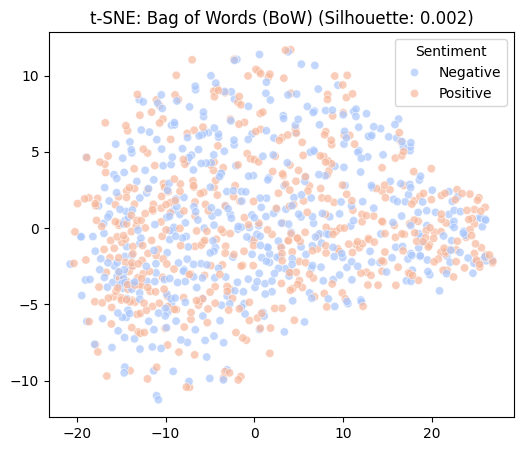

TF-IDF
--- TF-IDF (1,2,3-grams) ---
Kích thước ma trận: 1000x1000 | Sparsity: 89.41%
Sim cùng lớp (Pos-Pos): 0.2712 | Sim khác lớp (Pos-Neg): 0.2718
Silhouette Score: 0.0030

Đã lưu biểu đồ tại: ..\data\processed\processed_text\tsne_TF-IDF_(1,2,3-grams).png


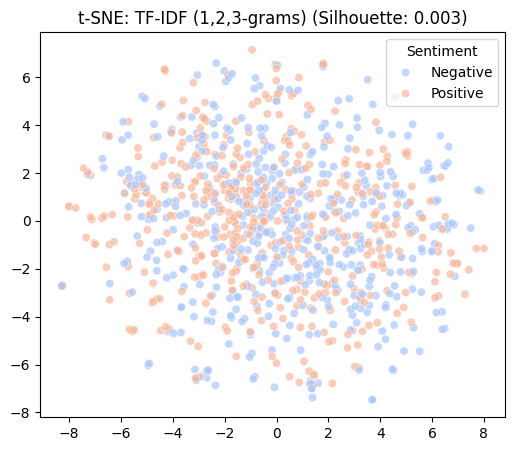

Word2Vec
--- Word2Vec (Average) ---
Kích thước ma trận: 1000x100 | Sparsity: 0.00%
Sim cùng lớp (Pos-Pos): 0.9933 | Sim khác lớp (Pos-Neg): 0.9932
Silhouette Score: 0.0172

Đã lưu biểu đồ tại: ..\data\processed\processed_text\tsne_Word2Vec_(Average).png


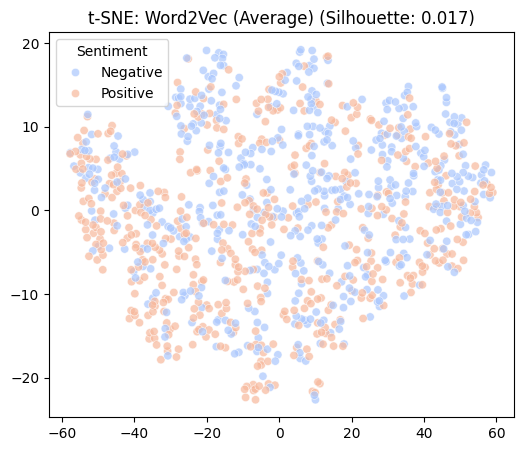

In [16]:

subset_df = df_clean.sample(1000, random_state=42)
X_texts = subset_df['cleaned_text']
y_labels = subset_df['sentiment'].map({'positive': 1, 'negative': 0})

def analyze_vectorization(X_matrix, y, name):
    # (i) Số chiều và độ thưa
    n_samples, n_features = X_matrix.shape
    
    # Tính sparsity (Kiểm tra xem X_matrix có phải là sparse matrix không)
    if hasattr(X_matrix, "nnz"):
        sparsity = 1.0 - (X_matrix.nnz / (n_samples * n_features))
    else: # Dành cho Word2Vec (Dense matrix)
        zero_elements = np.count_nonzero(X_matrix == 0)
        sparsity = zero_elements / (n_samples * n_features)
        
    print(f"--- {name} ---")
    print(f"Kích thước ma trận: {n_samples}x{n_features} | Sparsity: {sparsity*100:.2f}%")
    
    # (ii) Cosine Similarity (Cùng lớp vs Khác lớp)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    
    # Lấy tối đa 50 cặp ngẫu nhiên để tính 
    np.random.shuffle(pos_idx); np.random.shuffle(neg_idx)
    min_len = min(50, len(pos_idx), len(neg_idx))
    
    # Phải check hasattr toarray vì Word2Vec bản chất đã là mảng NumPy
    X_to_calc = X_matrix.toarray() if hasattr(X_matrix, "toarray") else X_matrix
    
    same_class_sim = cosine_similarity(X_to_calc[pos_idx[:min_len]], X_to_calc[pos_idx[min_len:min_len*2]]).mean()
    diff_class_sim = cosine_similarity(X_to_calc[pos_idx[:min_len]], X_to_calc[neg_idx[:min_len]]).mean()
    print(f"Sim cùng lớp (Pos-Pos): {same_class_sim:.4f} | Sim khác lớp (Pos-Neg): {diff_class_sim:.4f}")
    
    # (iii) t-SNE và Silhouette Score (Trực quan hóa)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_to_calc)
    
    sil_score = silhouette_score(X_to_calc, y)
    print(f"Silhouette Score: {sil_score:.4f}\n")
    
    # TẠO NHÃN MÀU 
    hue_labels = ['Positive' if val == 1 else 'Negative' for val in y]
    
    # Vẽ đồ thị
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=hue_labels, palette='coolwarm', alpha=0.7)
    plt.title(f"t-SNE: {name} (Silhouette: {sil_score:.3f})")
    plt.legend(title='Sentiment')
    save_path = os.path.join(SAVE_DIR, f"tsne_{name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    plt.show()

# 1. BoW
print("BoW")
bow = CountVectorizer(max_features=1000)
X_bow = bow.fit_transform(X_texts)
analyze_vectorization(X_bow, y_labels.values, "Bag of Words (BoW)")

# 2. TF-IDF (n-gram 1, 2, 3)
print("TF-IDF")
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=1000)
X_tfidf = tfidf.fit_transform(X_texts)
analyze_vectorization(X_tfidf, y_labels.values, "TF-IDF (1,2,3-grams)")

# 3. Word2Vec
print("Word2Vec")
sentences = [text.split() for text in X_texts]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def document_vector(doc):
    words = [w for w in doc.split() if w in w2v_model.wv]
    if len(words) == 0: return np.zeros(100)
    return np.mean(w2v_model.wv[words], axis=0)

X_w2v = np.array([document_vector(text) for text in X_texts])
analyze_vectorization(X_w2v, y_labels.values, "Word2Vec (Average)")

Vector hóa (BoW, TF-IDF, Word2Vec) và không gian đặc trưng (t-SNE, Silhouette)
- Dùng 3 phương pháp Vector hóa là BoW, TF-IDF, Word2Vec và so sánh các giá trị sparsity, Consine Similarity, Silhouette ta thấy
    + Xét Sparsity
        + BoW và IF-IDF có Sparsity rất lớn là 91.12% và 89.41%, đây là do 1 sample là review thì không quá dài như sparsity lại xét các từ trên sample đó với tất cả các loại từ của dataset -> phần lớn từ có trong dataset mà không có trong sample, nếu ma trận chứa nhiều số 0 như vậy thì việc tính toán sẽ tốn chi phí và chậm
        + Word2Vec thì có Sparsity = 0% do nó biểu diễn lại các chữ thành vector có kích thước là 100 là những con số và hầu hết là khác 0 nên sparsity mới bằng 0%
    + Xét giá trị Cosine Similarity
        + Consine Similarity của Bow ở khác lớp là 0.5878 lại cao hơn cừng lớp là 0.5716, do BoW là đếm tần suất của các từ nên cả review tích cực hay tiêu cực đều chứa các từ chung chung, làm BoW nhầm tưởng và không cho kết quả tốt
        +  TF-IDF thì đỡ hơn khi giá trị ở cùng lớp lớn hơn khác lớp, giá trị consine similarity cũng giảm xuống khoảng ~0.25 với 0.2597 ở cùng lớp và 0.2368 ở khác lớp là do TF-IDF đã giảm trọng số các từ xuất hiện phổ biến ở tài liệu, tăng ảnh hưởng của các từ đặc trưng
        +  Cosine Similarity rất cao vào khoảng 0.99 ở cả 2 trường hợp do Word2Vec lấy trung bình vector của các từ trong văn bản, giá trị này tương đối giống nhau ở các bài review nên làm tưởng các bài review giống nhau dù chúng khác về sentiment, Word2Vec thể hiện tốt được nghĩa cuar 1 từ riêng lẻ nhưng khi tính trung bình rất nhiều vector thứ tự, ngữ pháp hay các từ mang giá trị thể hiện cảm xúc bị mờ đi
    + Xét Silhouette và đồ thị t_SNE
        + Silhouette của cả 3 phương pháp đều rất thấp với Word2Vec > IF-IDF > BoW nhưng chỉ trong khoảng từ 0.0018 -> 0.0172, cùng với đồ thị t-SNE có các điểm khác lớp vẫn đề lên nhau không phân cụm rõ ràng thì thấy phương pháp này chưa tốt -> sentiment là một đặc trưng khó phân tách, không thể dùng các phương pháp trên để gom cụm

### 2.2.6 Biểu diễn ngữ nghĩa bằng Sentence Transformer
Sentence Transformer (SBERT) biến câu/văn bản → vector dense sao cho: Các câu có nghĩa giống nhau → vector gần nhau trong không gian.

$$
\mathbf{v}_d = f_\theta(d) \in \mathbb{R}^k
$$
- Trong đó:
    - fθ: mô hình pretrained
    - k: số chiều (thường 384 hoặc 768)

Phân cụm (K-Means)
$$
\min \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

Silhouette Score
$$
s = \frac{b - a}{\max(a, b)}
$$
- Trong đó
    - a: khoảng cách nội cụm
    - b: khoảng cách cụm khác

Phân loại (Linear SVM)
$$
f(x) = w^T x + b
$$
- Ý nghĩa: Tìm hyperplane phân tách dữ liệu

d:\Study\Data_Mining\Group_3\venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Đang mã hóa văn bản bằng Sentence Transformer...


Batches: 100%|██████████| 32/32 [00:42<00:00,  1.34s/it]



Đang thực hiện K-Means Clustering...
K-Means Silhouette (TF-IDF): 0.0181
K-Means Silhouette (Sentence Transformer): 0.0395

Đang vẽ đồ thị các cụm K-Means...
Đã lưu biểu đồ tại: ..\data\processed\processed_text\kmeans_K-Means_Clusters_TF-IDF_Silhouette_0.0181.png


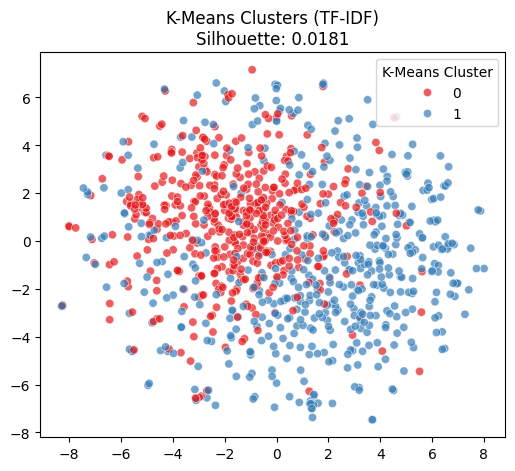

Đã lưu biểu đồ tại: ..\data\processed\processed_text\kmeans_K-Means_Clusters_Sentence_Transformer_Silhouette_0.0395.png


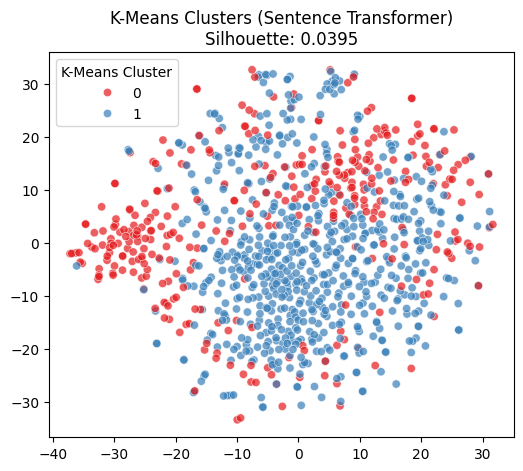


Đang đánh giá Linear SVM...


d:\Study\Data_Mining\Group_3\venv\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\Study\Data_Mining\Group_3\venv\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\Study\Data_Mining\Group_3\venv\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\Study\Data_Mining\Group_3\venv\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\Study\Data_Mining\Gro

Linear SVM Accuracy (TF-IDF): 0.7630
Linear SVM Accuracy (Sentence Transformer): 0.7970


d:\Study\Data_Mining\Group_3\venv\lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [18]:
# 1. Tải mô hình Pre-trained và encode
model_st = SentenceTransformer('all-MiniLM-L6-v2')
print("Đang mã hóa văn bản bằng Sentence Transformer...")
# Dùng X_texts và y_labels từ các bước trước
X_st = model_st.encode(X_texts.tolist(), show_progress_bar=True)

# 2. Phân cụm không giám sát (K-Means k=2)
print("\nĐang thực hiện K-Means Clustering...")
kmeans_tfidf = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_tfidf)
sil_kmeans_tfidf = silhouette_score(X_tfidf.toarray(), kmeans_tfidf.labels_)

kmeans_st = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_st)
sil_kmeans_st = silhouette_score(X_st, kmeans_st.labels_)

print(f"K-Means Silhouette (TF-IDF): {sil_kmeans_tfidf:.4f}")
print(f"K-Means Silhouette (Sentence Transformer): {sil_kmeans_st:.4f}\n")

# 3. Vẽ đồ thị biểu diễn các cụm K-Means
def plot_kmeans_clusters(X_data, cluster_labels, title):
    # Dùng t-SNE để giảm chiều dữ liệu về 2D cho việc vẽ hình
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_dense = X_data.toarray() if hasattr(X_data, "toarray") else X_data
    X_2d = tsne.fit_transform(X_dense)
    
    plt.figure(figsize=(6, 5))
    # Tô màu theo nhãn cụm mà K-Means dự đoán được (0 và 1)
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=cluster_labels, palette='Set1', alpha=0.7)
    plt.title(title)
    plt.legend(title='K-Means Cluster')
    
    safe_title = title.replace('\n', '_').replace(':', '').replace(' ', '_').replace('(', '').replace(')', '')
    save_path = os.path.join(SAVE_DIR, f"kmeans_{safe_title}.png")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    plt.show()

print("Đang vẽ đồ thị các cụm K-Means...")
plot_kmeans_clusters(X_tfidf, kmeans_tfidf.labels_, f"K-Means Clusters (TF-IDF)\nSilhouette: {sil_kmeans_tfidf:.4f}")
plot_kmeans_clusters(X_st, kmeans_st.labels_, f"K-Means Clusters (Sentence Transformer)\nSilhouette: {sil_kmeans_st:.4f}")

# 4. Phân loại có giám sát (Linear SVM)
print("\nĐang đánh giá Linear SVM...")
svm_tfidf = LinearSVC(random_state=42)
acc_tfidf = np.mean(cross_val_score(svm_tfidf, X_tfidf, y_labels, cv=5))

svm_st = LinearSVC(random_state=42)
acc_st = np.mean(cross_val_score(svm_st, X_st, y_labels, cv=5))

print(f"Linear SVM Accuracy (TF-IDF): {acc_tfidf:.4f}")
print(f"Linear SVM Accuracy (Sentence Transformer): {acc_st:.4f}")

Biểu diễn ngữ nghĩa bằng Sentence Transformer dùng mô hình all-MiniLM-L6-v2

Theo K-Means Clustering
- Giá trị Silhouette của Sentence Transformer tăng lên thành 0.0348, gần gấp đôi so với TF-IDF, có thể khi giảm chiều thì giữa các câu có liên kết, cấu trúc chặt chẽ hơn
- Mặc dù giá trị Silhouette vẫn còn thấp, điều này cho thấy bài toán phân cụm văn bản vốn dĩ khó do các lớp có thể chồng lấn về ngữ nghĩa. Tuy nhiên, việc cải thiện đáng kể Silhouette Score cho thấy Sentence Transformer đã giúp các văn bản có ý nghĩa tương tự được biểu diễn gần nhau hơn trong không gian vector, từ đó tạo ra các cụm rõ ràng hơn so với TF-IDF
- Điều này phản ánh rằng Sentence Transformer không chỉ dựa vào tần suất từ mà còn nắm bắt được cấu trúc ngữ nghĩa tiềm ẩn của câu

Theo Linear SVM
- Khi đưa bài toán về có giám sát, Accuracy của Sentence Transformer tăng lên 79.7%, lớn hơn TF-IDF khoảng 3%, vì TF-IDF tách từ và chấm điểm nên chưa hiểu được ngữ cảnh, còn Sentence Transformer dùng Self-Attention và bidirectional nên hiểu ngữ cảnh tốt hơn
- Ngoài ra, embedding của Sentence Transformer là dạng dense vector, giúp giảm sparsity so với TF-IDF, từ đó mô hình học ổn định và hiệu quả hơn
- Không gian đặc trưng của Sentence Transformer có xu hướng tuyến tính hơn, giúp Linear SVM dễ dàng tìm được hyperplane phân tách giữa các lớp
Điều này cho thấy Sentence Transformer không chỉ cải thiện về mặt biểu diễn mà còn giúp nâng cao khả năng tổng quát hóa của mô hình trên dữ liệu chưa thấy

Đã lưu bảng tổng hợp tại: ..\data\processed\processed_text\preprocessing_strategy_table.png


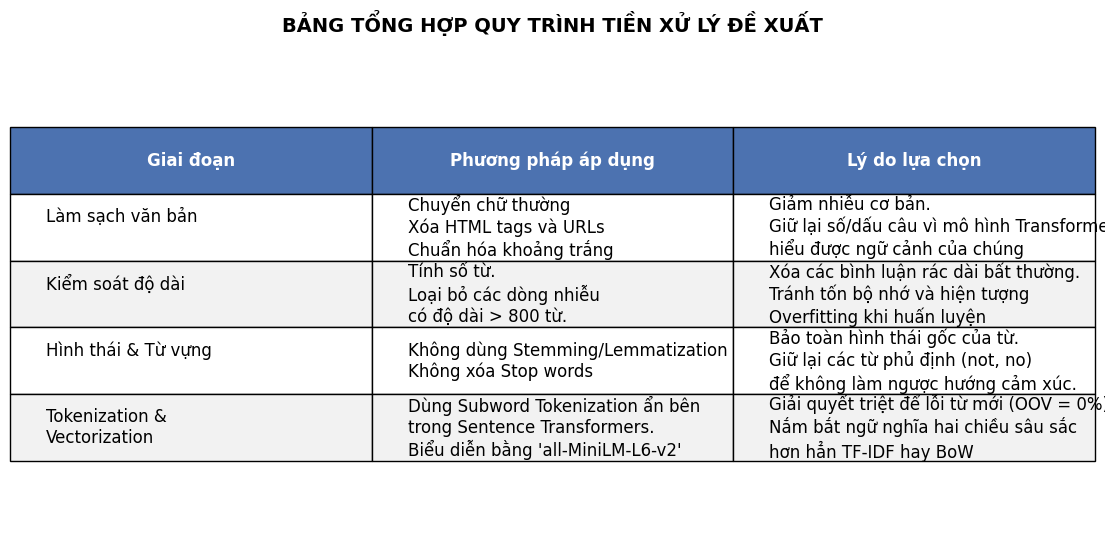

In [23]:
table_data = [
    ["Làm sạch văn bản\n", 
     "Chuyển chữ thường\nXóa HTML tags và URLs\nChuẩn hóa khoảng trắng", 
     "Giảm nhiễu cơ bản.\nGiữ lại số/dấu câu vì mô hình Transformer\nhiểu được ngữ cảnh của chúng"],
    
    ["Kiểm soát độ dài\n", 
     "Tính số từ.\nLoại bỏ các dòng nhiễu\ncó độ dài > 800 từ.", 
     "Xóa các bình luận rác dài bất thường.\nTránh tốn bộ nhớ và hiện tượng \nOverfitting khi huấn luyện"],
    
    ["Hình thái & Từ vựng\n", 
     "Không dùng Stemming/Lemmatization\nKhông xóa Stop words", 
     "Bảo toàn hình thái gốc của từ.\nGiữ lại các từ phủ định (not, no) \nđể không làm ngược hướng cảm xúc."],
    
    ["Tokenization &\nVectorization", 
     "Dùng Subword Tokenization ẩn bên \ntrong Sentence Transformers.\nBiểu diễn bằng 'all-MiniLM-L6-v2'", 
     "Giải quyết triệt để lỗi từ mới (OOV = 0%).\nNắm bắt ngữ nghĩa hai chiều sâu sắc \nhơn hẳn TF-IDF hay BoW"]
]

columns = ["Giai đoạn", "Phương pháp áp dụng", "Lý do lựa chọn"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

# Tạo bảng
table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='left')

# Format style cho bảng đẹp hơn
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 4) # Kéo giãn chiều cao các hàng

# Tô màu tiêu đề
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4c72b0') # Màu xanh biển
    else:
        cell.set_facecolor('#f2f2f2' if row % 2 == 0 else 'white') # Trắng xám xen kẽ

plt.title("BẢNG TỔNG HỢP QUY TRÌNH TIỀN XỬ LÝ ĐỀ XUẤT", fontweight="bold", fontsize=14, y=1.05)

# 4. Lưu ảnh
save_path_table = os.path.join(SAVE_DIR, 'preprocessing_strategy_table.png')
plt.savefig(save_path_table, dpi=300, bbox_inches='tight')
print(f"Đã lưu bảng tổng hợp tại: {save_path_table}")

plt.show()

In [ ]:
# 1. Hàm làm sạch văn bản
def clean_text_optimized(text):
    text = str(text).lower() # Chuyển chữ thường
    text = re.sub(r'<.*?>', ' ', text) # Xóa HTML tags
    text = re.sub(r'http\S+|www\S+', '', text) # Xóa URLs
    text = re.sub(r'\s+', ' ', text).strip() # Xóa khoảng trắng thừa
    return text

df['cleaned_text'] = df['review'].apply(clean_text_optimized)

# 2. Xóa Outliers
df['word_count_new'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df_final = df[df['word_count_new'] <= 800].copy()
print(f"Đã giữ lại {len(df_final)}/{len(df)} mẫu sau khi lọc nhiễu chiều dài.")

# 3. Lưu Text đã làm sạch ra file CSV
save_path_csv = os.path.join(SAVE_DIR, 'final_cleaned_dataset.csv')
df_final.to_csv(save_path_csv, index=False)
print(f"Đã lưu Text sạch tại: {save_path_csv}")

# ==========================================
# 4. VECTOR HÓA BẰNG SENTENCE TRANSFORMER
# ==========================================
print("\nĐang khởi tạo Sentence Transformer (Subword Tokenization có sẵn bên trong)...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Chuyển list text thành Vector 
print("Đang mã hóa văn bản thành Vector")
embeddings = model.encode(df_final['cleaned_text'].tolist(), show_progress_bar=True)

# 5. Lưu ma trận Vector ra file Numpy (.npy) vì lưu ra CSV sẽ rất nặng và dễ lỗi
save_path_vector = os.path.join(SAVE_DIR, 'sentence_embeddings.npy')
np.save(save_path_vector, embeddings)
print(f"Đã lưu Ma trận Vector (Kích thước {embeddings.shape}) tại: {save_path_vector}")

print("\nHoàn tất quy trình xử lý")

Đã giữ lại 9845/10000 mẫu sau khi lọc nhiễu chiều dài.
Đã lưu Text sạch tại: ..\data\processed\processed_text\final_cleaned_dataset.csv

Đang khởi tạo Sentence Transformer (Subword Tokenization có sẵn bên trong)...


d:\Study\Data_Mining\Group_3\venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Đang mã hóa văn bản thành Vector


Batches: 100%|██████████| 308/308 [08:27<00:00,  1.65s/it]


Đã lưu Ma trận Vector (Kích thước (9845, 384)) tại: ..\data\processed\processed_text\sentence_embeddings.npy

QUY TRÌNH TIỀN XỬ LÝ ĐÃ HOÀN TẤT. BẠN CÓ THỂ ĐEM FILE ĐI TRAIN MÔ HÌNH!


# KẾT LUẬN

Từ quá trình thực nghiệm, phân tích thống kê và đánh giá các kỹ thuật xử lý ngôn ngữ tự nhiên trên tập dữ liệu đánh giá phim, đồ án rút ra những kết luận quan trọng sau đây:

### 1. Đặc điểm phân phối và tính chất thống kê của văn bản
- **Về độ dài và phân phối:** Cả hai lớp bình luận tích cực và tiêu cực đều có phân phối lệch phải. Đáng chú ý, các bình luận tiêu cực có xu hướng dài hơn một chút so với tích cực (trung bình 233 từ so với 230 từ). Kiểm định Mann-Whitney U ($P-value < 0.05$) khẳng định sự khác biệt này là có ý nghĩa thống kê. Sự xuất hiện của các giá trị ngoại lai có độ dài vượt trội đòi hỏi phải có bước cắt tỉa độ dài để tránh gây nhiễu, tốn bộ nhớ và làm mô hình quá khớp.
- **Về độ phong phú từ vựng:** Giá trị TTR ở mức thấp (~0.07) và tuân thủ chặt chẽ định luật phân phối Zipf cho thấy ngôn ngữ sử dụng mang tính tự nhiên cao nhưng độ đa dạng không lớn. Các từ có tần suất cao nhất chủ yếu là hư từ (stop words). 

### 2. Đánh giá tác động của Pipeline Tiền xử lý và Tokenization
- **Chuẩn hóa văn bản:** Việc làm sạch dữ liệu (đặc biệt là loại bỏ ký tự đặc biệt và số) giúp giảm đáng kể không gian từ vựng và hạn chế nhiễu. Tuy nhiên, quá trình này đòi hỏi sự đánh đổi vì có thể làm mất đi các đặc trưng định lượng có giá trị cảm xúc (ví dụ: "10/10", "A+").
- **Chiến lược Tokenization:** Trong 4 chiến lược được thử nghiệm, **Subword Tokenization (BPE)** chứng minh sự vượt trội hoàn toàn. Kỹ thuật này giải quyết được điểm yếu của các phương pháp khác khi duy trì được lượng từ vựng ở mức tối ưu 4974 tokens, tỷ lệ OOV trên tập test đạt **0%**, đồng thời giữ được độ dài chuỗi xử lý trung bình ở mức hợp lý 277.4.

### 3. Tác động ngược của Stop words, Stemming và Lemmatization
Thực nghiệm cho thấy không phải kỹ thuật chuẩn hóa nào cũng mang lại lợi ích cho bài toán phân loại cảm xúc:
- **Loại bỏ Stop words:** Làm giảm giá trị Thông tin tương hỗ (MI), đồng nghĩa với việc vô tình loại bỏ một số từ mang tính đảo ngược ngữ nghĩa (như *not, no*). Tuy nhiên, về mặt tổng thể, việc này giúp mô hình chạy nhanh hơn và tăng nhẹ Accuracy do loại bỏ được lượng lớn độ nhiễu.
- **Stemming và Lemmatization:** Porter và Snowball Stemmer bộc lộ sự hạn chế với Collision Rate lên tới hơn 32%, cắt từ thô bạo và làm mất nghĩa gốc. Lemmatization (WordNet) tốt hơn với tỷ lệ va chạm ~10%. Tuy nhiên, cả ba phương pháp **đều làm giảm hiệu năng phân loại** của mô hình Logistic Regression. Điều này cho thấy đối với bài toán cảm xúc tiếng Anh, việc giữ nguyên hình thái từ gốc mang lại giá trị phân loại tốt hơn.

### 4. Không gian đặc trưng và Biểu diễn ngữ nghĩa (Vectorization)
- **Các phương pháp truyền thống (BoW, TF-IDF):** Gặp vấn đề lớn với Sparsity ~90%, gây tốn kém chi phí tính toán. BoW bộc lộ yếu điểm lớn khi Cosine Similarity khác lớp lại cao hơn cùng lớp. TF-IDF khắc phục được một phần điều này nhờ việc đánh trọng số đặc trưng tốt hơn.
- **Biểu diễn Dense (Word2Vec):** Mặc dù giải quyết được vấn đề độ thưa, nhưng việc lấy trung bình vector cho toàn bộ văn bản đã làm mờ đi các từ mang đặc trưng cảm xúc cốt lõi, khiến Cosine Similarity giữa mọi văn bản đều xấp xỉ 0.99.
- **Phân tách không gian (Clustering):** Đồ thị t-SNE và điểm Silhouette của cả BoW, TF-IDF và Word2Vec đều rất thấp. Điều này chứng tỏ "cảm xúc" là một ranh giới phi tuyến tính rất phức tạp, không thể phân tách rõ ràng bằng các phương pháp gom cụm không giám sát cơ bản.

### 5. Sự vượt trội của Sentence Transformer trong bài toán có giám sát
- Dù sử dụng mô hình pre-trained *all-MiniLM-L6-v2* trong không gian không giám sát chưa mang lại sự tách biệt rõ ràng về cụm cảm xúc do mô hình thiên về bắt cấu trúc ngữ nghĩa câu. 
- Tuy nhiên, khi kết hợp không gian vector sinh bởi **Sentence Transformer với mô hình Linear SVM** (học có giám sát), hiệu năng phân loại đạt **79.7%** (cao hơn TF-IDF 3%). Nhờ cơ chế Self-Attention và ngữ cảnh hai chiều, Sentence Transformer đã nắm bắt thành công sự liên kết từ vựng và ngữ cảnh sâu xa mà các phương pháp đếm tần suất đơn thuần không thể làm được.

### Tổng kết
Quá trình phân tích và thực nghiệm cho thấy đối với bài toán phân tích cảm xúc, **Subword Tokenization (BPE)** kết hợp với các mô hình biểu diễn ngữ cảnh sâu như **Sentence Transformers** là phương pháp tối ưu nhất. Các kỹ thuật xử lý văn bản truyền thống Stemming, loại bỏ Stop words, BoW không những không mang lại lợi ích mà còn có nguy cơ làm rớt thông tin, giảm hiệu suất tổng thể của mô hình.